# Phase 2: Visualisations

Visualising the DDPM trained on FashionMNIST (200 epochs, loaded from checkpoint).

**Sections:**
1. Setup & model loading
2. Forward diffusion process: x₀ → x_T (noise progression)
3. Reverse denoising process: x_T → x₀ (intermediate steps)
4. T=1000 vs T=250 sampling comparison
5. Large sample grid (64 images)

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
np.Inf = np.inf
import math
import time

from tqdm import tqdm
from torchvision.utils import make_grid
from torchvision.datasets import FashionMNIST
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

In [4]:
# Hyperparameters (must match training)
dataset_path        = '~/datasets'
DEVICE              = torch.device('cuda' if torch.cuda.is_available() else
                      'mps' if torch.backends.mps.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

img_size               = (28, 28, 1)
timestep_embedding_dim = 256
hidden_dim             = 256
n_timesteps            = 1000
beta_minmax            = [1e-4, 2e-2]
inference_batch_size   = 64
seed                   = 1234

torch.manual_seed(seed)
np.random.seed(seed)

Using device: mps


In [5]:
# Model architecture (identical to training notebook)
class SinusoidalPosEmb(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, x):
        device   = x.device
        half_dim = self.dim // 2
        emb      = math.log(10000) / (half_dim - 1)
        emb      = torch.exp(torch.arange(half_dim, device=device) * -emb)
        emb      = x[:, None] * emb[None, :]
        emb      = torch.cat((emb.sin(), emb.cos()), dim=-1)
        return emb


class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.GroupNorm(8, out_channels),
            nn.SiLU(),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.GroupNorm(8, out_channels),
            nn.SiLU()
        )

    def forward(self, x):
        return self.double_conv(x)


class UNet(nn.Module):
    def __init__(self, image_resolution, hidden_dims=[64, 128, 256],
                 diffusion_time_embedding_dim=256, n_times=1000):
        super().__init__()
        _, _, img_C = image_resolution

        self.time_embedding = SinusoidalPosEmb(diffusion_time_embedding_dim)
        self.time_project   = nn.Sequential(
            nn.Linear(diffusion_time_embedding_dim, hidden_dims[0]),
            nn.SiLU(),
            nn.Linear(hidden_dims[0], hidden_dims[0])
        )

        self.inc   = DoubleConv(img_C, hidden_dims[0])
        self.down1 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(hidden_dims[0], hidden_dims[1]))
        self.down2 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(hidden_dims[1], hidden_dims[2]))

        self.up1      = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.conv_up1 = DoubleConv(hidden_dims[2] + hidden_dims[1], hidden_dims[1])
        self.up2      = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.conv_up2 = DoubleConv(hidden_dims[1] + hidden_dims[0], hidden_dims[0])
        self.outc     = nn.Conv2d(hidden_dims[0], img_C, kernel_size=1)

    def forward(self, x, diffusion_timestep):
        t_emb = self.time_embedding(diffusion_timestep)
        t_emb = self.time_project(t_emb).unsqueeze(-1).unsqueeze(-2)

        x1 = self.inc(x) + t_emb
        x2 = self.down1(x1)
        x3 = self.down2(x2)

        x  = self.up1(x3)
        x  = self.conv_up1(torch.cat([x, x2], dim=1))
        x  = self.up2(x)
        x  = self.conv_up2(torch.cat([x, x1], dim=1))
        return self.outc(x)


class Diffusion(nn.Module):
    def __init__(self, model, image_resolution=[32,32,3],
                 n_times=1000, beta_minmax=[1e-4, 2e-2], device='cpu'):
        super().__init__()
        self.n_times = n_times
        self.img_H, self.img_W, self.img_C = image_resolution
        self.model  = model
        self.device = device

        beta_1, beta_T = beta_minmax
        betas = torch.linspace(beta_1, beta_T, n_times).to(device)
        self.sqrt_betas = torch.sqrt(betas)

        self.alphas                    = 1 - betas
        self.sqrt_alphas               = torch.sqrt(self.alphas)
        alpha_bars                     = torch.cumprod(self.alphas, dim=0)
        self.sqrt_alpha_bars           = torch.sqrt(alpha_bars)
        self.sqrt_one_minus_alpha_bars = torch.sqrt(1 - alpha_bars)

    def extract(self, a, t, x_shape):
        b, *_ = t.shape
        out   = a.gather(-1, t)
        return out.reshape(b, *((1,) * (len(x_shape) - 1)))

    def scale_to_minus_one_to_one(self, x):
        return x * 2 - 1

    def reverse_scale_to_zero_to_one(self, x):
        return (x + 1) * 0.5

    def make_noisy(self, x_zeros, t):
        epsilon        = torch.randn_like(x_zeros).to(self.device)
        sqrt_alpha_bar = self.extract(self.sqrt_alpha_bars, t, x_zeros.shape)
        sqrt_one_minus = self.extract(self.sqrt_one_minus_alpha_bars, t, x_zeros.shape)
        noisy_sample   = x_zeros * sqrt_alpha_bar + epsilon * sqrt_one_minus
        return noisy_sample.detach(), epsilon

    def forward(self, x_zeros):
        x_zeros = self.scale_to_minus_one_to_one(x_zeros)
        B       = x_zeros.shape[0]
        t       = torch.randint(0, self.n_times, (B,)).long().to(self.device)
        perturbed, epsilon = self.make_noisy(x_zeros, t)
        pred_epsilon       = self.model(perturbed, t)
        return perturbed, epsilon, pred_epsilon

    def denoise_at_t(self, x_t, timestep, t):
        z = torch.randn_like(x_t).to(self.device) if t > 1 else torch.zeros_like(x_t).to(self.device)
        epsilon_pred             = self.model(x_t, timestep)
        alpha                    = self.extract(self.alphas,                    timestep, x_t.shape)
        sqrt_alpha               = self.extract(self.sqrt_alphas,               timestep, x_t.shape)
        sqrt_one_minus_alpha_bar = self.extract(self.sqrt_one_minus_alpha_bars, timestep, x_t.shape)
        sqrt_beta                = self.extract(self.sqrt_betas,                timestep, x_t.shape)
        x_t_minus_1 = (1 / sqrt_alpha) * (x_t - (1 - alpha) / sqrt_one_minus_alpha_bar * epsilon_pred) + sqrt_beta * z
        return x_t_minus_1.clamp(-1., 1.)

    def sample(self, N):
        x_t = torch.randn((N, self.img_C, self.img_H, self.img_W)).to(self.device)
        for t in range(self.n_times - 1, -1, -1):
            timestep = torch.tensor([t]).repeat_interleave(N, 0).long().to(self.device)
            x_t      = self.denoise_at_t(x_t, timestep, t)
        return self.reverse_scale_to_zero_to_one(x_t)

In [6]:
# Load dataset
transform    = transforms.Compose([transforms.ToTensor()])
test_dataset = FashionMNIST(dataset_path, transform=transform, train=False, download=True)
test_loader  = DataLoader(test_dataset, batch_size=inference_batch_size, shuffle=False,
                          num_workers=4, pin_memory=True)

# Class labels come directly from the dataset
print(f'Classes: {test_dataset.classes}')
print(f'Test set: {len(test_dataset)} images')

Classes: ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
Test set: 10000 images


In [7]:
# Initialise model and load 200-epoch checkpoint
model    = UNet(image_resolution=img_size, hidden_dims=[64, 128, 256],
                diffusion_time_embedding_dim=timestep_embedding_dim,
                n_times=n_timesteps).to(DEVICE)

diffusion = Diffusion(model, image_resolution=img_size, n_times=n_timesteps,
                      beta_minmax=beta_minmax, device=DEVICE).to(DEVICE)

checkpoint = torch.load('models/unet_checkpoint_ep200.pt', map_location=DEVICE)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

print(f"\u2705 Loaded checkpoint from epoch {checkpoint['epoch']}")
print(f"   Final training loss: {checkpoint['loss']:.4f}")

✅ Loaded checkpoint from epoch 200
   Final training loss: 0.0360


/var/folders/v4/wh4l29gn14b9m0c46dzl2hjc0000gn/T/ipykernel_92481/629860625.py:9: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load('models/unet_checkpoin

## Section 1 — Forward Diffusion Process: x₀ → x_T

Each row shows one FashionMNIST image at increasing noise levels.  
The forward process is: `x_t = √ᾱ_t · x₀ + √(1−ᾱ_t) · ε`  where `ε ~ N(0,I)`.

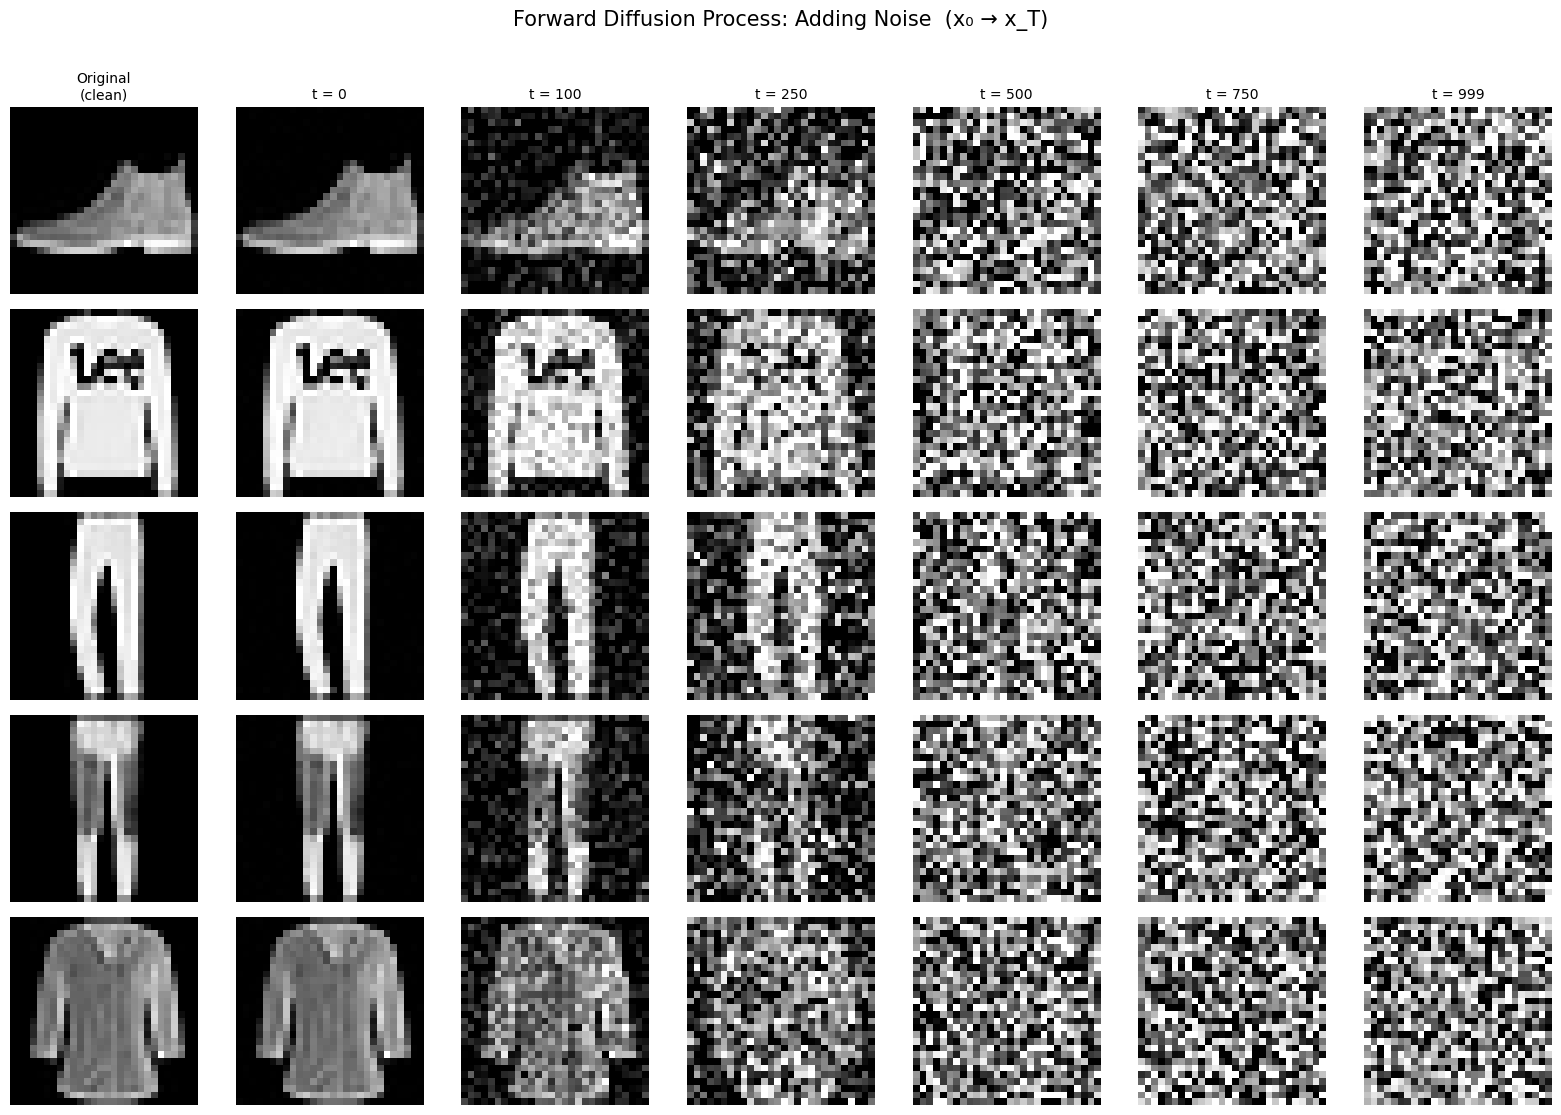

Saved: forward_process.png


In [8]:
# Grab one batch of test images
for x_batch, label_batch in test_loader:
    x_batch     = x_batch.to(DEVICE)
    label_batch = label_batch
    break

n_show   = 5
x_show   = x_batch[:n_show]
lbl_show = label_batch[:n_show]

timesteps_fwd = [0, 100, 250, 500, 750, 999]
x_scaled = diffusion.scale_to_minus_one_to_one(x_show)

fig, axes = plt.subplots(n_show, len(timesteps_fwd) + 1,
                         figsize=(16, n_show * 2.2))
fig.suptitle('Forward Diffusion Process: Adding Noise  (x₀ → x_T)', fontsize=15, y=1.01)

for row in range(n_show):
    # Original clean image (label comes from the dataset itself)
    axes[row, 0].imshow(x_show[row, 0].cpu().numpy(), cmap='gray', vmin=0, vmax=1)
    axes[row, 0].set_ylabel(test_dataset.classes[lbl_show[row].item()], fontsize=9)
    if row == 0:
        axes[row, 0].set_title('Original\n(clean)', fontsize=10)
    axes[row, 0].axis('off')

    for col, t_val in enumerate(timesteps_fwd):
        t_tensor      = torch.tensor([t_val]).long().to(DEVICE)
        noisy, _      = diffusion.make_noisy(x_scaled[row:row+1], t_tensor)
        noisy_display = diffusion.reverse_scale_to_zero_to_one(noisy)
        img_np        = noisy_display[0, 0].detach().cpu().numpy()
        axes[row, col + 1].imshow(np.clip(img_np, 0, 1), cmap='gray', vmin=0, vmax=1)
        if row == 0:
            axes[row, col + 1].set_title(f't = {t_val}', fontsize=10)
        axes[row, col + 1].axis('off')

plt.tight_layout()
plt.savefig('forward_process.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: forward_process.png')

## Section 2 — Reverse Denoising Process: x_T → x₀

Starting from pure Gaussian noise, the model iteratively predicts and removes noise.  
Each column captures the image at a different remaining-timestep `t`.

In [9]:
def sample_with_intermediates(diffusion, N=4, capture_at=None):
    """Run full reverse diffusion and capture intermediate images at requested timesteps."""
    capture_at = set(capture_at or [750, 500, 250, 100, 50, 0])
    x_t = torch.randn((N, diffusion.img_C, diffusion.img_H, diffusion.img_W)).to(diffusion.device)

    # Save the initial pure noise for display
    intermediates = {'noise': diffusion.reverse_scale_to_zero_to_one(x_t.clone()).detach().cpu()}

    with torch.no_grad():
        for t in tqdm(range(diffusion.n_times - 1, -1, -1), desc='Reverse diffusion', leave=True):
            timestep = torch.tensor([t]).repeat_interleave(N, 0).long().to(diffusion.device)
            x_t = diffusion.denoise_at_t(x_t, timestep, t)
            if t in capture_at:
                intermediates[t] = diffusion.reverse_scale_to_zero_to_one(x_t.clone()).detach().cpu()

    return diffusion.reverse_scale_to_zero_to_one(x_t).detach().cpu(), intermediates

Reverse diffusion: 100%|██████████| 1000/1000 [00:06<00:00, 145.13it/s]


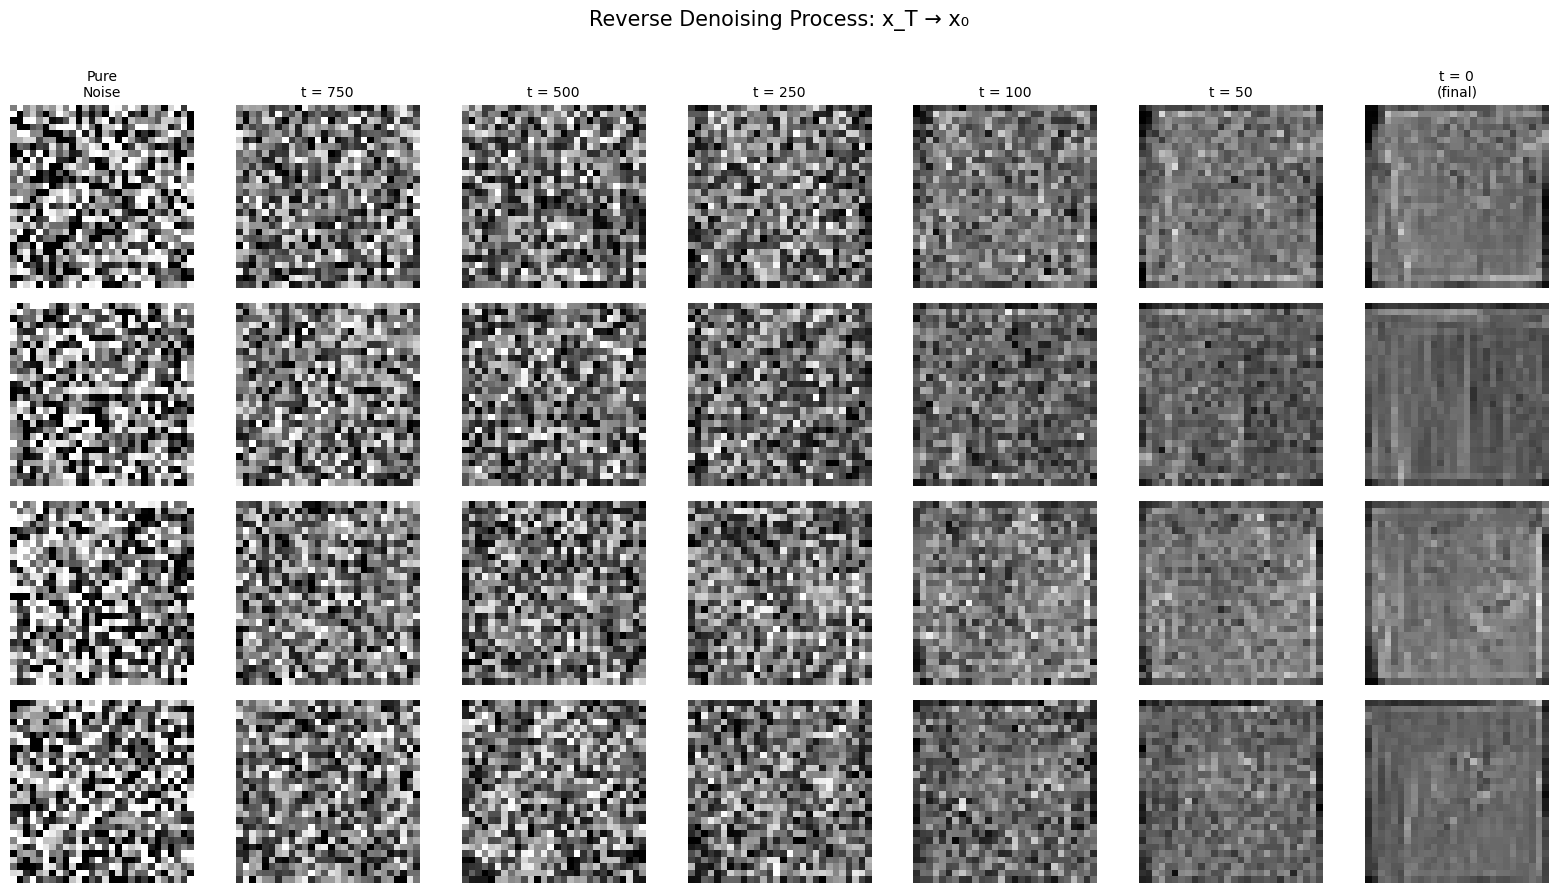

Saved: reverse_process.png


In [10]:
N_rev         = 4
capture_steps = [750, 500, 250, 100, 50, 0]

x_final, intermediates = sample_with_intermediates(diffusion, N=N_rev, capture_at=capture_steps)

col_keys   = ['noise'] + capture_steps
col_labels = ['Pure\nNoise'] + [f't = {t}' if t > 0 else 't = 0\n(final)' for t in capture_steps]

fig, axes = plt.subplots(N_rev, len(col_keys), figsize=(16, N_rev * 2.2))
fig.suptitle('Reverse Denoising Process: x_T → x₀', fontsize=15, y=1.01)

for row in range(N_rev):
    for col, key in enumerate(col_keys):
        img = np.clip(intermediates[key][row, 0].numpy(), 0, 1)
        axes[row, col].imshow(img, cmap='gray', vmin=0, vmax=1)
        if row == 0:
            axes[row, col].set_title(col_labels[col], fontsize=10)
        axes[row, col].axis('off')

plt.tight_layout()
plt.savefig('reverse_process.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: reverse_process.png')

## Section 3 — T=1000 vs T=250 Sampling Speed Comparison

Full DDPM sampling requires 1000 sequential denoising steps.  
A common speed-up is to skip timesteps — here we run every 4th step (250 steps total).  
Note: proper fast sampling uses DDIM; this is a simple demonstration of the quality/speed trade-off.

In [11]:
def fast_sample(diffusion, N=8, n_steps=250):
    """Approximate fast sampling via uniform timestep skipping."""
    step_ratio   = diffusion.n_times // n_steps
    timestep_seq = list(range(0, diffusion.n_times, step_ratio))[::-1]
    x_t = torch.randn((N, diffusion.img_C, diffusion.img_H, diffusion.img_W)).to(diffusion.device)
    with torch.no_grad():
        for t in tqdm(timestep_seq, desc=f'Fast sample (T={n_steps})', leave=True):
            timestep = torch.tensor([t]).repeat_interleave(N, 0).long().to(diffusion.device)
            x_t = diffusion.denoise_at_t(x_t, timestep, t)
    return diffusion.reverse_scale_to_zero_to_one(x_t).detach().cpu()


N_cmp = 8

print('T=1000 (full) …')
t0 = time.time()
with torch.no_grad():
    x_full = diffusion.sample(N_cmp).detach().cpu()
t_full = time.time() - t0
print(f'  Done in {t_full:.1f}s')

print('T=250 (fast) …')
t0 = time.time()
x_fast = fast_sample(diffusion, N=N_cmp, n_steps=250)
t_fast = time.time() - t0
print(f'  Done in {t_fast:.1f}s  ({t_full/t_fast:.1f}× speed-up)')

T=1000 (full) …
  Done in 9.2s
T=250 (fast) …


Fast sample (T=250): 100%|██████████| 250/250 [00:02<00:00, 110.86it/s]

  Done in 2.3s  (4.1× speed-up)


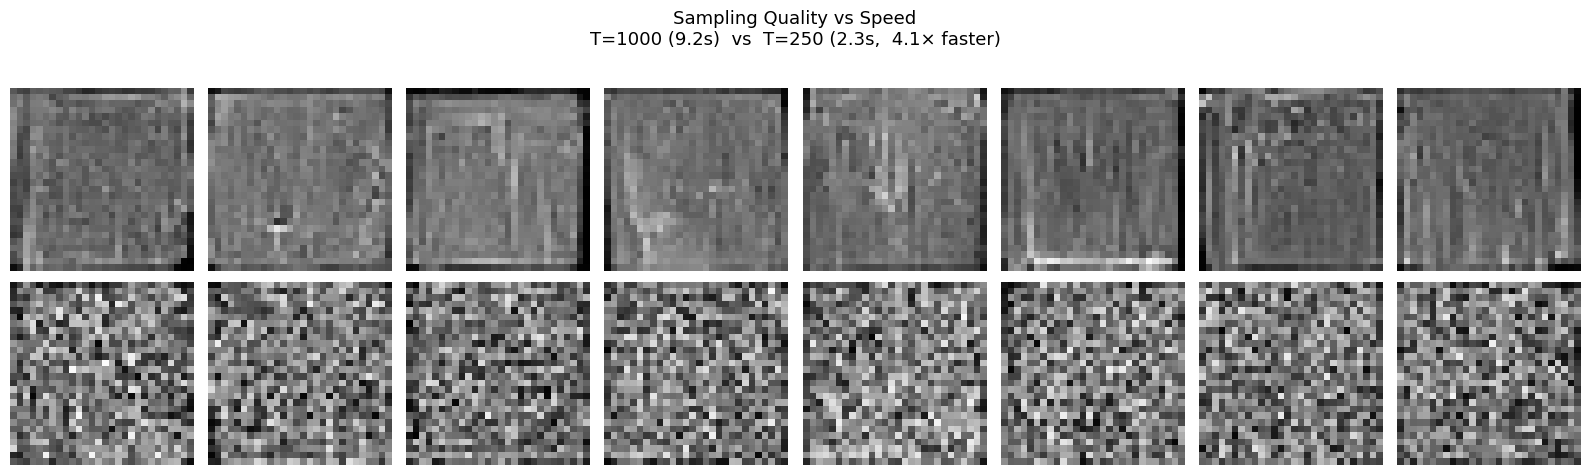

Saved: t1000_vs_t250.png


In [12]:
fig, axes = plt.subplots(2, N_cmp, figsize=(16, 5))
fig.suptitle(
    f'Sampling Quality vs Speed\n'
    f'T=1000 ({t_full:.1f}s)  vs  T=250 ({t_fast:.1f}s,  {t_full/t_fast:.1f}× faster)',
    fontsize=13
)

for i in range(N_cmp):
    axes[0, i].imshow(x_full[i, 0].numpy(), cmap='gray', vmin=0, vmax=1)
    axes[0, i].axis('off')
    axes[1, i].imshow(x_fast[i, 0].numpy(), cmap='gray', vmin=0, vmax=1)
    axes[1, i].axis('off')

axes[0, 0].set_ylabel('T=1000\n(full)', fontsize=11)
axes[1, 0].set_ylabel('T=250\n(fast)', fontsize=11)

plt.tight_layout()
plt.savefig('t1000_vs_t250.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: t1000_vs_t250.png')

## Section 4 — Generated Sample Grid (64 images)

Generating 64 samples …


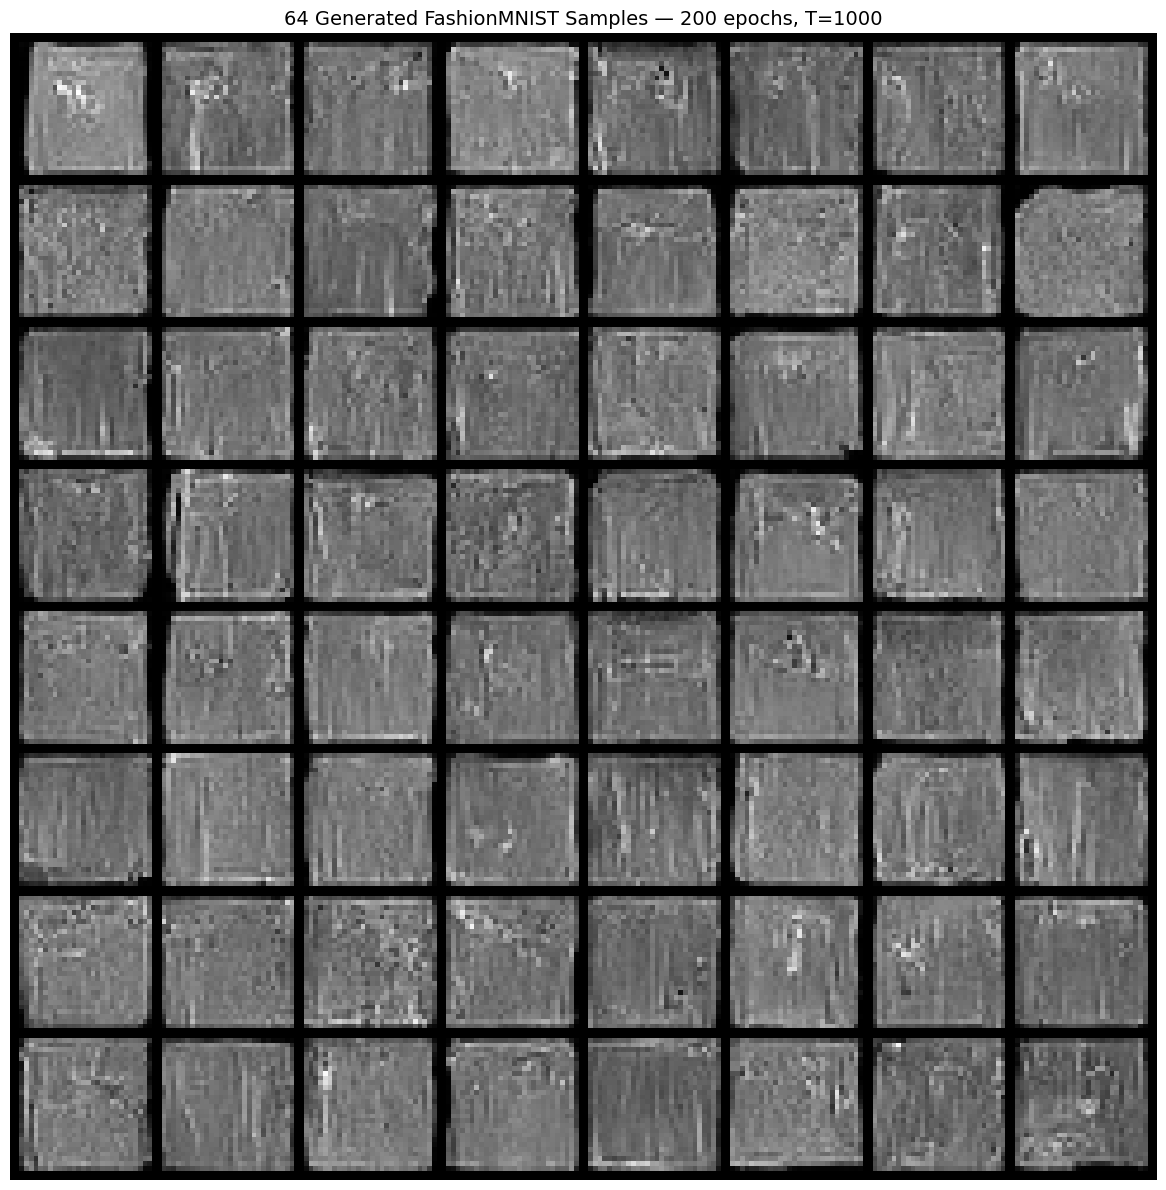

Saved: generated_grid_64.png


In [13]:
print('Generating 64 samples …')
with torch.no_grad():
    samples = diffusion.sample(N=64).detach().cpu()

grid    = make_grid(samples, nrow=8, padding=2, normalize=True)
grid_np = grid.permute(1, 2, 0).numpy()

plt.figure(figsize=(12, 12))
plt.imshow(grid_np, cmap='gray')
plt.title('64 Generated FashionMNIST Samples — 200 epochs, T=1000', fontsize=14)
plt.axis('off')
plt.tight_layout()
plt.savefig('generated_grid_64.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: generated_grid_64.png')